In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wordcloud import WordCloud, STOPWORDS

In [26]:
%pip install scikit-learn pandas


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
%pwd
df = pd.read_csv("../sampleddata.csv")
print(df.shape)
df.head()

(25731, 22)


,id,text,epoch,media,retweetedTweet,lang,rawContent,cleanedTweet,replyCount,retweetCount,...,hashtags,mentionedUsers,links,viewCount,quotedTweet,in_reply_to_screen_name,location,user,date,week
0,1.822059e+18,@MTGrepp Hire his own private security.\nWe do...,1.723248e+09,[],False,en,@MTGrepp Hire his own private security.\nWe do...,Hire his own private security.We don’t trust F...,1.0,1.0,...,[],"[{'id_str': '1663701168839872512', 'name': 'Ma...",[],"{'count': '167', 'state': 'EnabledWithCount'}",False,MTGrepp,NaN,"{'id': 1700275343746375680, 'id_str': '1700275...",2024-08-09,14
1,1.822047e+18,"@RpsAgainstTrump @MikePence "" I can't vote for...",1.723245e+09,[],False,en,"@RpsAgainstTrump @MikePence "" I can't vote for...",""" I can't vote for Donald Trump because he tri...",0.0,0.0,...,[],"[{'id_str': '1221462414744596483', 'name': 'Re...",[],"{'count': '11', 'state': 'EnabledWithCount'}",False,RpsAgainstTrump,NaN,"{'id': 1463350602449055748, 'id_str': '1463350...",2024-08-09,14
2,1.822044e+18,From banning fracking to private health insura...,1.723244e+09,[],False,en,From banning fracking to private health insura...,From banning fracking to private health insura...,0.0,0.0,...,[],[],[{'display_url': 'washingtonexaminer.com/opini...,"{'count': '23', 'state': 'EnabledWithCount'}",False,NaN,NaN,"{'id': 1519815039145975809, 'id_str': '1519815...",2024-08-09,14
3,1.822047e+18,Share away.,1.723245e+09,[],False,en,Share away.,Share away.,0.0,0.0,...,[],[],[],"{'count': '45', 'state': 'EnabledWithCount'}",True,NaN,NaN,"{'id': 34396209, 'id_str': '34396209', 'url': ...",2024-08-09,14
4,1.822059e+18,@Arkypatriot FuckALLcensorship,1.723248e+09,[],False,en,@Arkypatriot FuckALLcensorship,FuckALLcensorship,1.0,0.0,...,[],"[{'id_str': '1077019129', 'name': 'USMC Lady V...",[],"{'count': '7', 'state': 'EnabledWithCount'}",False,Arkypatriot,NaN,"{'id': 1546569489491247104, 'id_str': '1546569...",2024-08-09,14


In [28]:
df.describe()

,id,epoch,replyCount,retweetCount,likeCount,quoteCount,week
count,2.573100e+04,2.573100e+04,25731.000000,25731.000000,25731.000000,25731.000000,25731.000000
mean,1.821739e+18,1.723171e+09,46.707163,125.625432,592.970192,7.220940,13.793246
std,2.196072e+16,5.235844e+06,781.186647,1554.005557,9461.016248,105.827581,8.657063
min,1.785460e+18,1.714522e+09,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.803812e+18,1.718897e+09,0.000000,0.000000,0.000000,0.000000,7.000000
50%,1.815038e+18,1.721574e+09,0.000000,0.000000,0.000000,0.000000,11.000000
75%,1.841152e+18,1.727800e+09,0.000000,0.000000,1.000000,0.000000,21.000000
max,1.863010e+18,1.733011e+09,54132.000000,84702.000000,670629.000000,5206.000000,30.000000


In [29]:
df.groupby('week')[['retweetCount','likeCount']].describe()

retweetCount                                                         \
            count         mean          std  min  25%  50%  75%      max   
week                                                                       
0           900.0    25.938889   371.367886  0.0  0.0  0.0  0.0  10424.0   
1          1000.0    43.879000   361.350711  0.0  0.0  0.0  0.0   3835.0   
2           540.0    33.240741   356.318307  0.0  0.0  0.0  0.0   7032.0   
3           740.0    70.682432   520.923735  0.0  0.0  0.0  0.0   8239.0   
4           719.0   109.166898   787.434224  0.0  0.0  0.0  0.0  11241.0   
5           818.0    67.023227   557.564140  0.0  0.0  0.0  0.0  12918.0   
6          1450.0    60.510345  1058.083336  0.0  0.0  0.0  0.0  37906.0   
7           940.0     7.887234   126.544482  0.0  0.0  0.0  0.0   2824.0   
8           645.0   149.275969  1064.686774  0.0  0.0  0.0  0.0  13040.0   
9          1235.0   139.323077  1650.968710  0.0  0.0  0.0  0.0  48517.0   
10         2385.0     1.734591    22.676702  0.0  0.0  0.0  0.0    904.0   
11         1980.0    36.071212   458.863519  0.0  0.0  0.0  0.0  11617.0   
12          420.0   389.347619  1997.031340  0.0  0.0  0.0  0.0  20627.0   
13           80.0     1.125000     5.027456  0.0  0.0  0.0  0.0     39.0   
14         1060.0     2.974528    40.077455  0.0  0.0  0.0  0.0   1082.0   
15         1140.0     5.454386   102.383931  0.0  0.0  0.0  0.0   3346.0   
16          200.0     1.645000    18.754135  0.0  0.0  0.0  0.0    264.0   
17          120.0     4.558333    45.900293  0.0  0.0  0.0  0.0    503.0   
18          184.0   628.907609  5647.543460  0.0  0.0  0.0  0.0  54217.0   
19          426.0    74.164319   693.690262  0.0  0.0  0.0  0.0   9830.0   
20         1169.0    74.256630  1184.072319  0.0  0.0  0.0  0.0  32064.0   
21         1326.0    29.468326   494.713331  0.0  0.0  0.0  0.0  14007.0   
22         1149.0   113.749347  1771.579319  0.0  0.0  0.0  0.0  41246.0   
23         1187.0   221.915754  1381.662374  0.0  0.0  0.0  0.0  14639.0   
24          338.0  1731.127219  5849.229413  0.0  0.0  0.0  0.0  36578.0   
25          460.0  1355.893478  6131.713423  0.0  0.0  0.0  0.0  84702.0   
26          360.0   986.630556  4464.674149  0.0  0.0  0.0  1.0  44991.0   
27          360.0   303.844444  1780.209569  0.0  0.0  0.0  0.0  20209.0   
28          840.0     1.083333    10.224895  0.0  0.0  0.0  0.0    204.0   
29         1020.0     2.551961    26.586837  0.0  0.0  0.0  0.0    605.0   
30          540.0     8.387037   109.616231  0.0  0.0  0.0  0.0   2157.0   

     likeCount                                                           
         count         mean           std  min  25%  50%  75%       max  
week                                                                     
0        900.0   124.153333   1645.083532  0.0  0.0  0.0  2.0   44345.0  
1       1000.0    37.600000    469.583945  0.0  0.0  0.0  2.0   13077.0  
2        540.0   162.016667   1536.748364  0.0  0.0  0.0  1.0   23783.0  
3        740.0   264.656757   1979.036138  0.0  0.0  0.0  1.0   25482.0  
4        719.0   431.378303   3479.973598  0.0  0.0  0.0  1.0   58116.0  
5        818.0   224.716381   2229.846986  0.0  0.0  0.0  1.0   47520.0  
6       1450.0    97.830345   1840.512539  0.0  0.0  0.0  1.0   65507.0  
7        940.0    15.603191    302.177463  0.0  0.0  0.0  1.0    9084.0  
8        645.0   118.376744   1249.819221  0.0  0.0  0.0  1.0   26580.0  
9       1235.0   111.878543   1666.428381  0.0  0.0  0.0  1.0   44972.0  
10      2385.0     8.295178    113.280437  0.0  0.0  0.0  1.0    5049.0  
11      1980.0   168.593939   2113.599136  0.0  0.0  0.0  1.0   47492.0  
12       420.0  1044.923810   6366.850508  0.0  0.0  0.0  1.0   84634.0  
13        80.0     3.812500     16.109667  0.0  0.0  0.0  1.0     130.0  
14      1060.0    15.659434    220.612929  0.0  0.0  0.0  1.0    6223.0  
15      1140.0    17.610526    223.570557  0.0  0.0  0.0  1.0    6501.0  
16       200.0

In [30]:
df['cleanedTweet']

0        Hire his own private security.We don’t trust F...
1        " I can't vote for Donald Trump because he tri...
2        From banning fracking to private health insura...
3                                              Share away.
4                                        FuckALLcensorship
                               ...                        
25726    And what did the Democratic Party do to get yo...
25727    You can’t have two masters ..The Democratic Pa...
25728    Opinion | Former Attorney General Alberto Gonz...
25729    The Green Party is no threat to capitalism or ...
25730    And we enjoyed every minute of it! Kamala Harr...
Name: cleanedTweet, Length: 25731, dtype: str

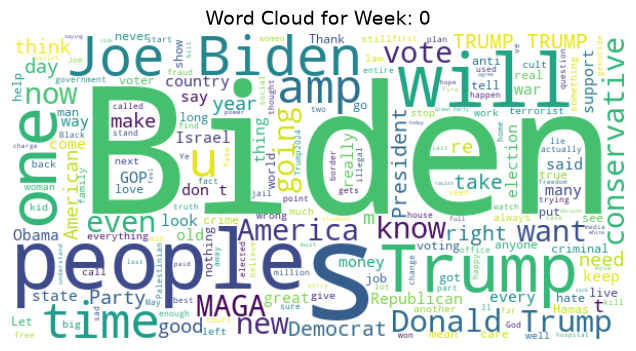

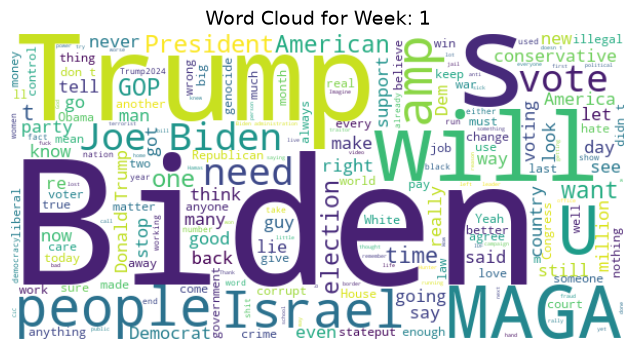

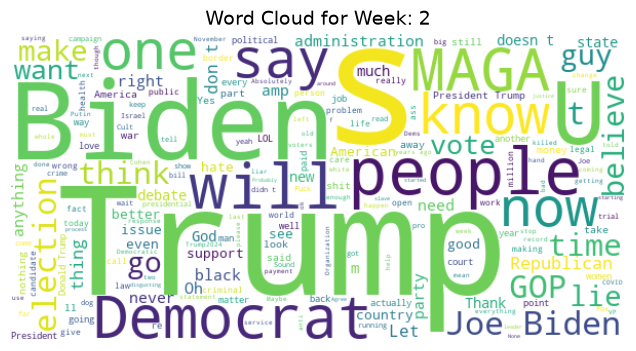

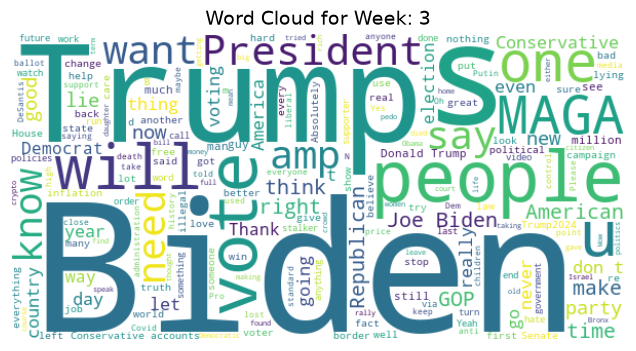

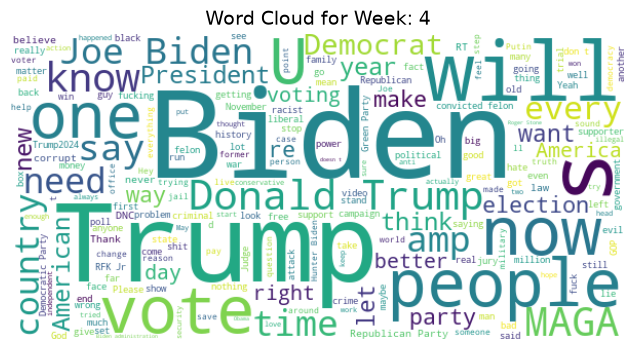

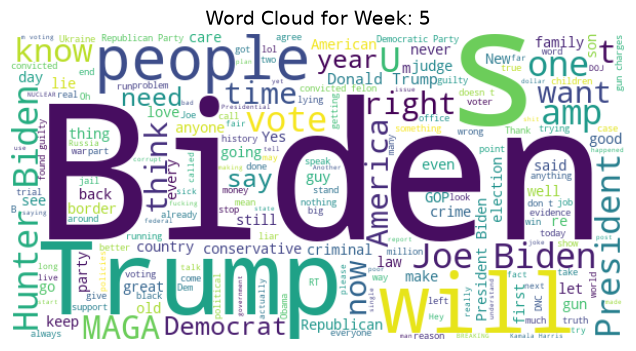

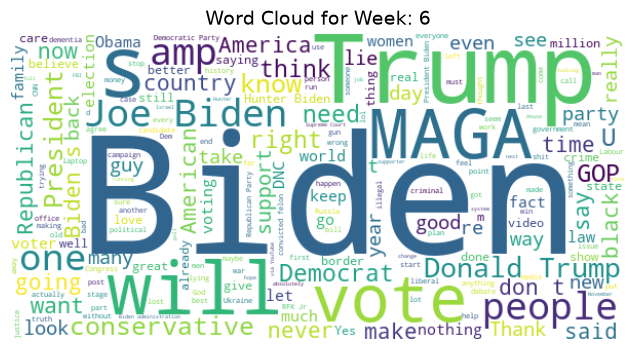

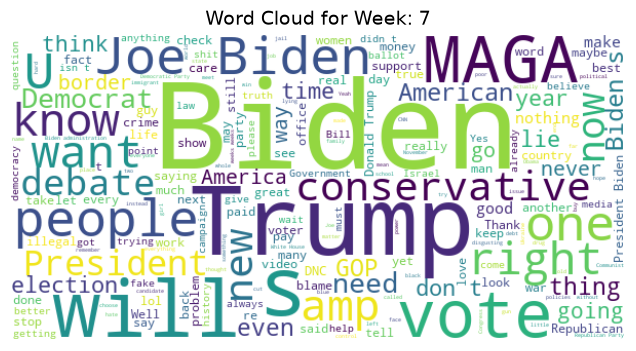

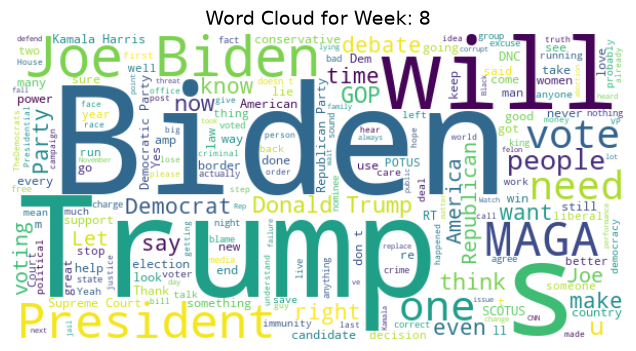

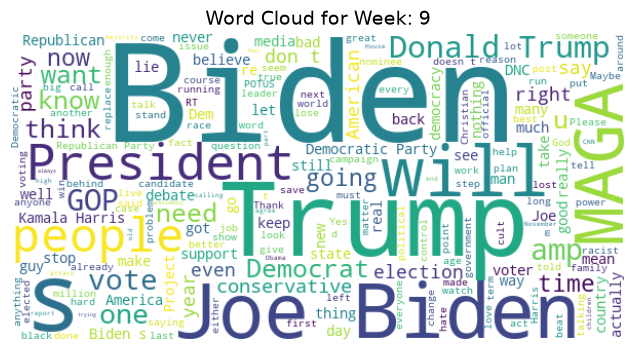

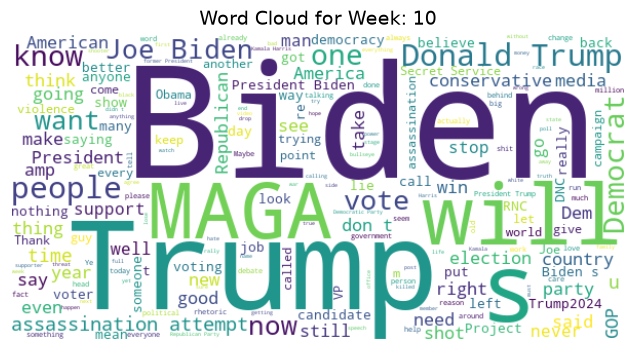

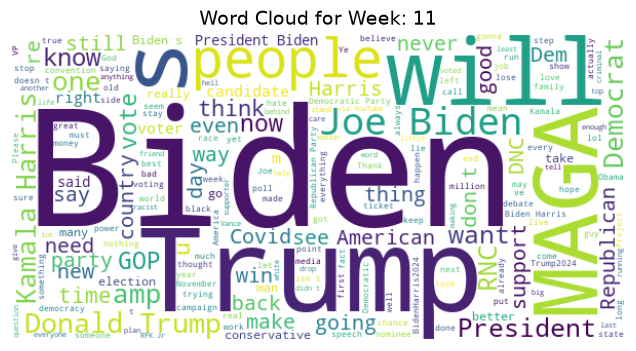

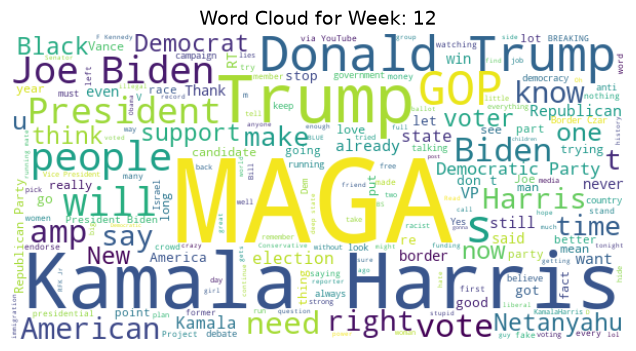

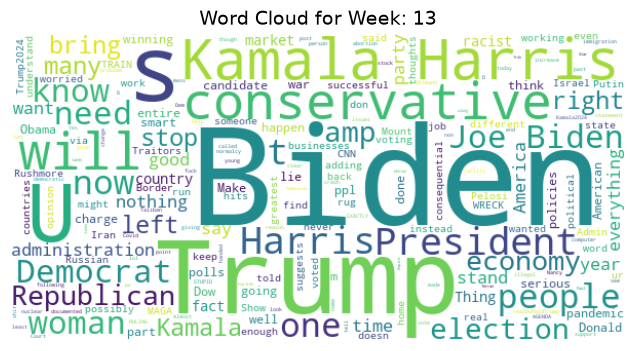

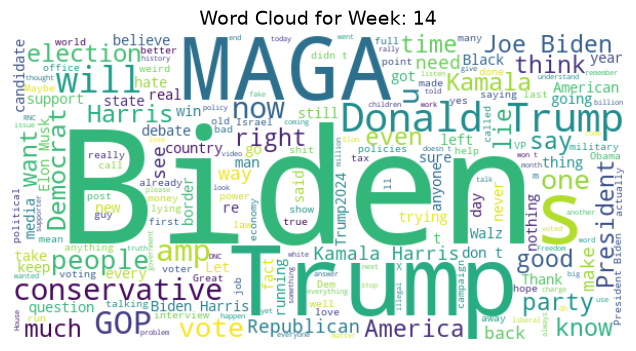

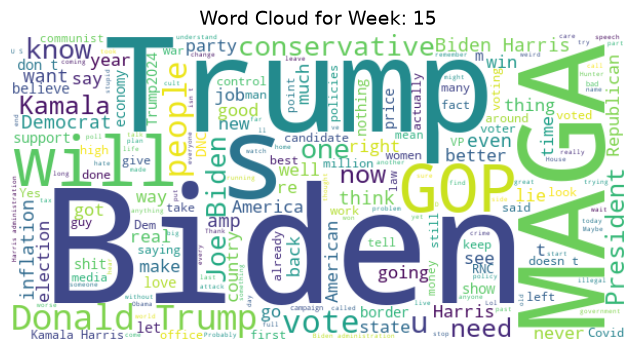

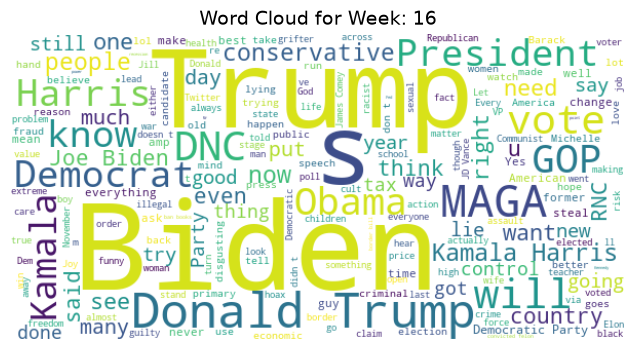

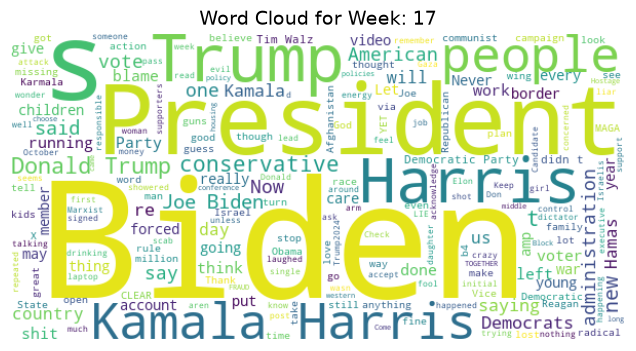

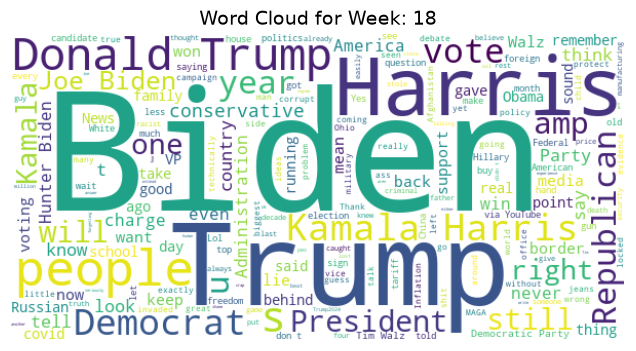

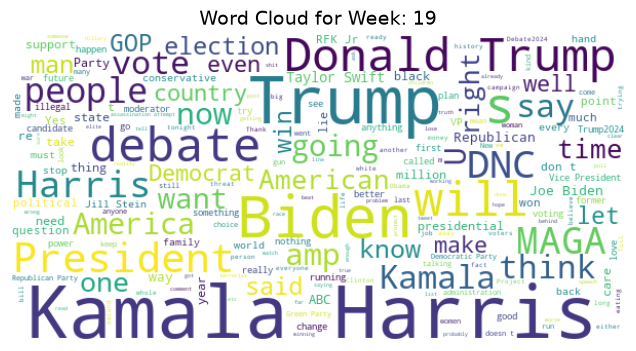

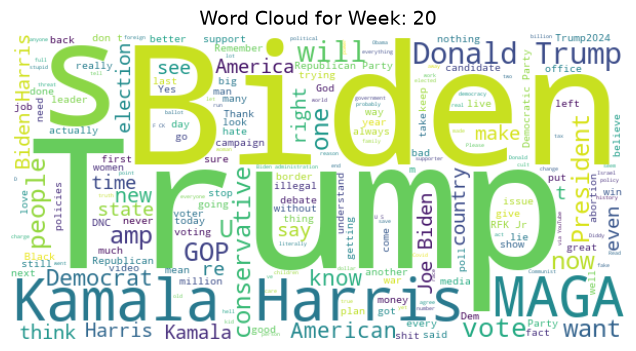

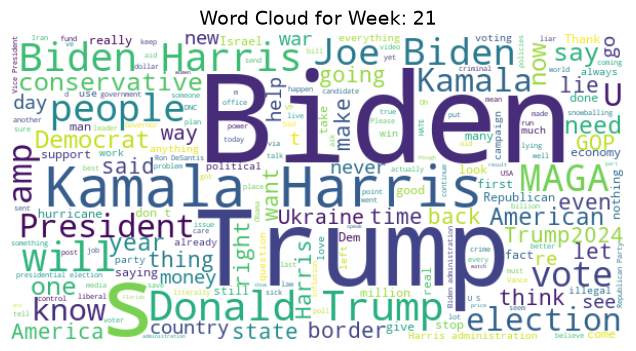

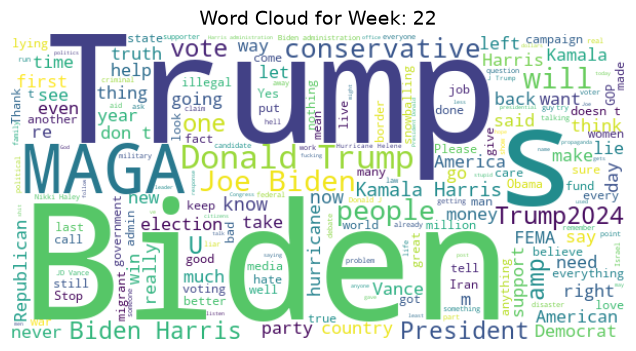

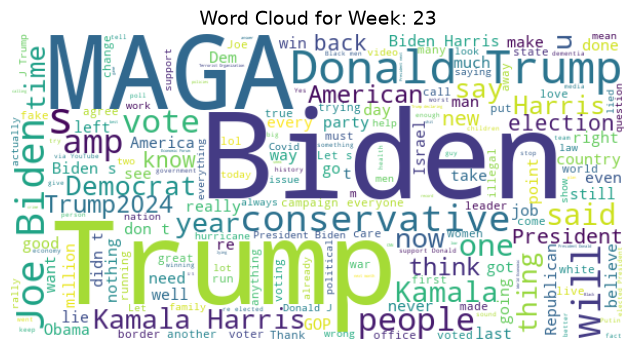

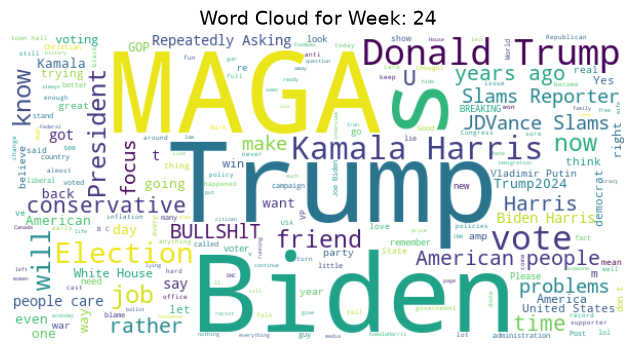

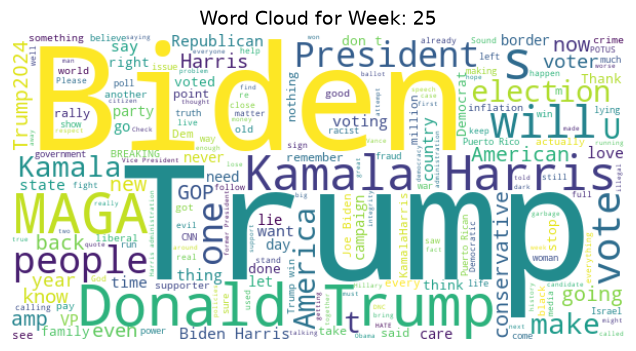

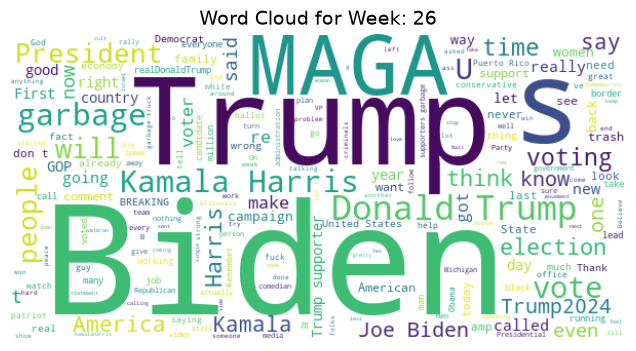

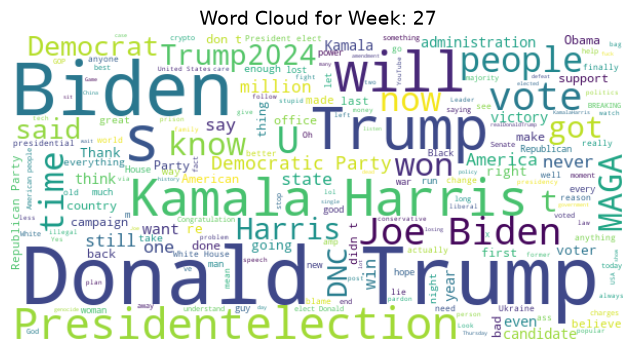

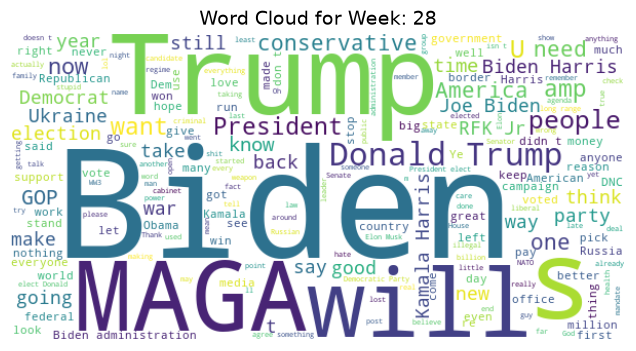

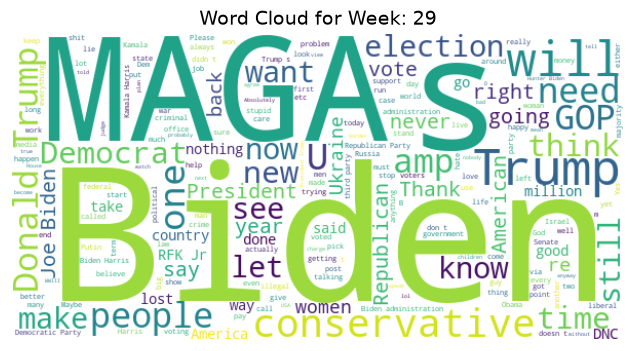

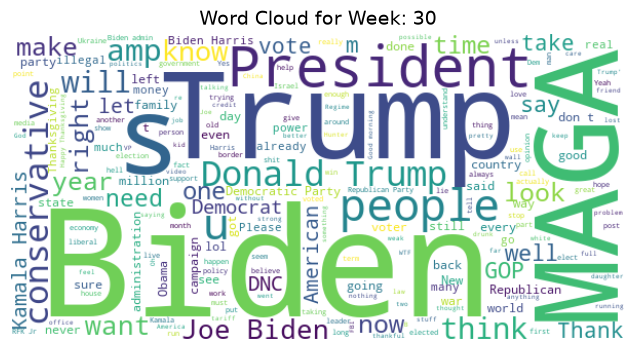

In [31]:
weekly_words = df.groupby('week')['cleanedTweet'].agg(' '.join)
stopwords = set(STOPWORDS)

for index, week in enumerate(weekly_words):
    # Generate the word cloud
    wordcloud = WordCloud(
        width=600,
        height=300,
        background_color='white',
        stopwords=set(STOPWORDS)
    ).generate(week)

    # Display the word cloud labeled by the week ending date
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for Week: {index}", fontsize=14)
    plt.axis('off')
    plt.show()

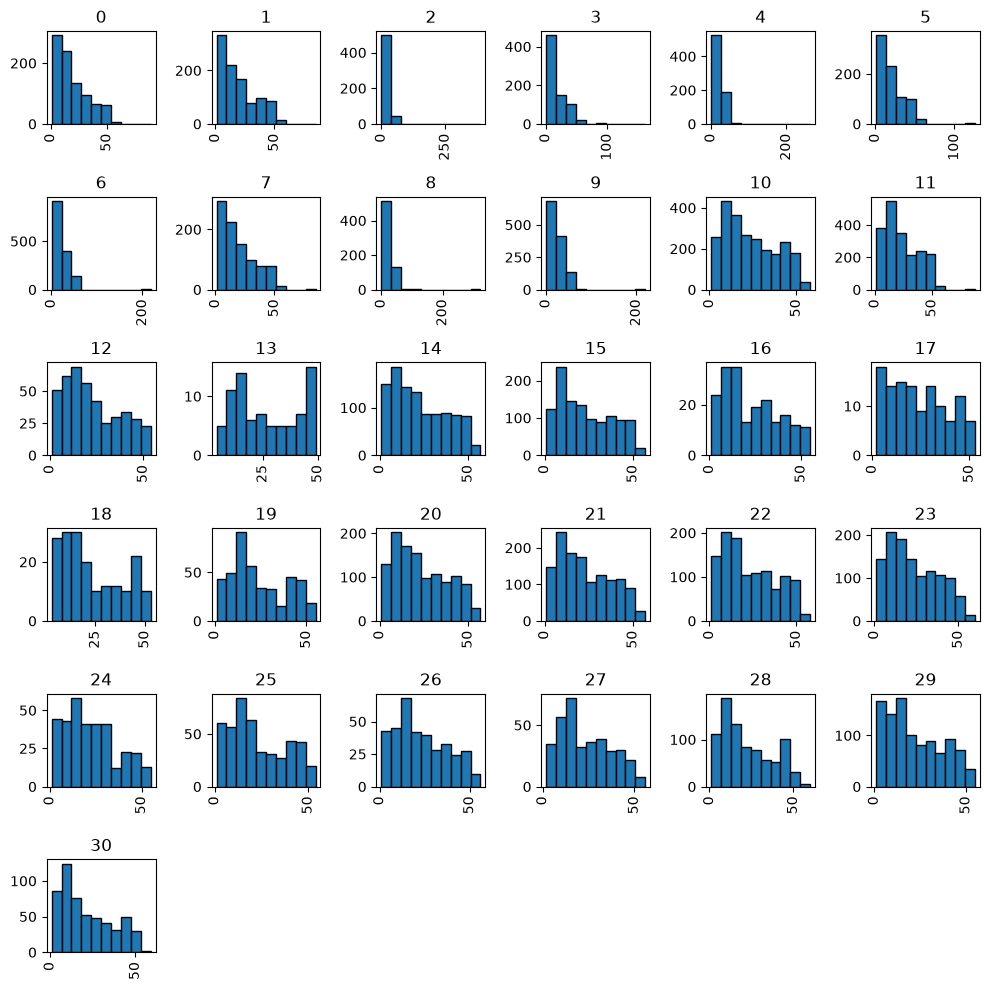

In [32]:
df['tweet_length'] = df['cleanedTweet'].str.split().str.len()
grouped = df.groupby('week')

df.hist(column='tweet_length', by='week', edgecolor='black',figsize=(10,10))
plt.tight_layout()
plt.show()

In [33]:
df.groupby('week')['tweet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,900.0,19.004444,14.355179,1.0,8.00,15.0,28.00,89.0
1,1000.0,19.559000,14.556112,1.0,8.00,15.0,29.00,85.0
2,540.0,16.840741,24.312220,1.0,6.00,11.0,21.00,388.0
3,740.0,18.214865,15.879913,1.0,7.00,12.5,26.25,162.0
4,719.0,20.112656,18.798813,1.0,8.00,15.0,28.50,263.0
5,818.0,19.738386,15.022953,1.0,8.00,16.0,28.00,126.0
6,1450.0,20.806207,16.603411,1.0,8.00,16.0,32.00,218.0
7,940.0,19.486170,14.223262,1.0,8.00,15.0,29.00,85.0
8,645.0,19.793798,19.559178,1.0,7.00,15.0,28.00,323.0


# Topic Modeling: LDA & NMF (TKG)


This portion of the notebook used unsupervised topic modeling (LDA and NMF) on the cleaned
tweets to identify the main discussion themes and track how they shift week
to week during the campaign.

In [34]:
#Uses Jesse's cleanedTweet column to drop missing values. 
docs=df["cleanedTweet"].dropna().astype(str)
#Creating a new dataframe with only tweets that have 5 or more words for meaningful for analysis.
docs=docs[docs.str.split().str.len() >= 5]
print(len(docs), "tweets used for topic modeling")
docs.head(10)

23563 tweets used for topic modeling


0     Hire his own private security.We don’t trust F...
1     " I can't vote for Donald Trump because he tri...
2     From banning fracking to private health insura...
5     maybe he’s just used to looking up and not dow...
6     We all know it’s not you Joe Biden running thi...
8     I got the most bills passed of GOP and second ...
9                Your words are words only MAGA speaks.
10    Your showing a segment about nuclear weapons l...
11    Dem policies:🍔Free school lunch👶Universal pre-...
12    But what would she do? Can you provide a link ...
Name: cleanedTweet, dtype: str

In [35]:
#Fit LDA and NMF models to the cleaned tweets. This will help identify underlying topics in the tweets.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Number of topics for topic modeling. This can be adjusted based on the desired granularity of topics.
N_TOPICS = 5

# LDA (Latent Dirichlet Allocation)
# max_df=0.95 ignores words that appear in more than 95% of tweets;
# min_df=5 ignores words that appear in fewer than 5 tweets
count_vec = CountVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_counts = count_vec.fit_transform(docs)
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42)
lda.fit(X_counts)

#NMF (Non-negative Matrix Factorization)
tfidf_vec = TfidfVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_tfidf = tfidf_vec.fit_transform(docs)
nmf = NMF(n_components=N_TOPICS, init="nndsvd", random_state=42)
nmf.fit(X_tfidf)

# random_state=42 makes results repeatable, so everyone gets the same topics




,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",'nndsvd'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary <random_state>`.",42
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [36]:
#TOPICS
# Prints the top words for each topic so we can interpret what each one is about
def show_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        #Sorts words by how strongly they belong to this topic and keep the top n
        top = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        print(f"Topic {i}: {', '.join(top)}")

# Compare the two models: which gives clearer, less overlapping topics?
print("--- LDA---")
show_topics(lda, count_vec)
print("\n--- NMF ---")
show_topics(nmf, tfidf_vec)

--- LDA---
Topic 0: trump, biden, donald, time, maga, like, just, jr, love, did
Topic 1: maga, biden, trump, vote, just, people, amp, don, like, conservative
Topic 2: biden, harris, kamala, joe, president, trump, administration, border, election, did
Topic 3: trump, donald, like, biden, conservative, president, people, don, want, american
Topic 4: biden, party, trump, republican, gop, like, democratic, people, just, obama

--- NMF ---
Topic 0: biden, joe, president, did, administration, said, years, hunter, didn, obama
Topic 1: trump, donald, president, america, election, 2024, support, assassination, youtube, elon
Topic 2: maga, america, cult, let, make, trump2024, love, trump, great, maha
Topic 3: harris, kamala, president, vp, vice, youtube, debate, border, campaign, voting
Topic 4: party, like, people, just, don, vote, conservative, gop, republican, know


<Axes: title={'center': 'NMF topic share by week'}, xlabel='week'>

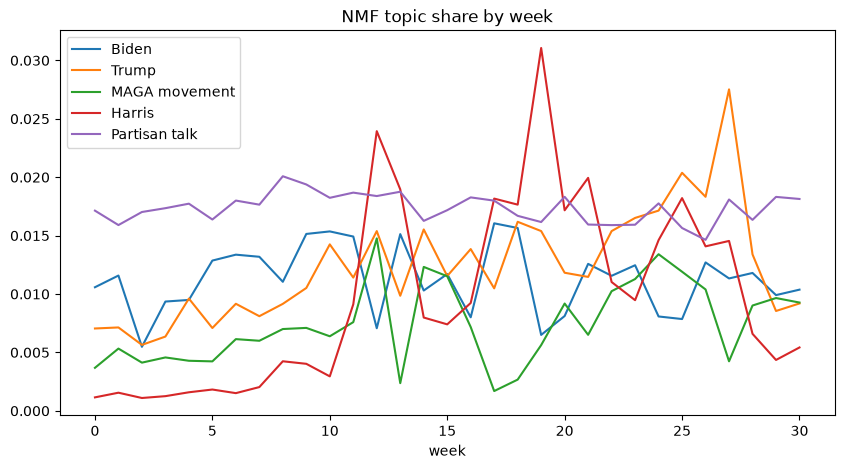

In [37]:
#Topics Over Time
# How much each of the NMF topics shows up in each week of the campaign;
# rising/falling lines show which narratives gained or lost attention
doc_topics = nmf.transform(X_tfidf)              
topic_df = pd.DataFrame(doc_topics, index=docs.index)
topic_df["week"] = df.loc[docs.index, "week"]    

weekly_topics = topic_df.groupby("week").mean()
weekly_topics.columns = [
    "Biden",
    "Trump",
    "MAGA movement",
    "Harris",
    "Partisan talk",
]
weekly_topics.plot(figsize=(10, 5), title="NMF topic share by week")

# Topic Matching and Shift Scoring

This portion of the notebook we topic matched by pairing each period's topics with the next period's most similar topics. secondly, we do shoift scoring to measure how much the issue's framing changed between periods.

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import jensenshannon

print(df.shape)
print(df.columns.tolist())

(25731, 23)
['id', 'text', 'epoch', 'media', 'retweetedTweet', 'lang', 'rawContent', 'cleanedTweet', 'replyCount', 'retweetCount', 'likeCount', 'quoteCount', 'hashtags', 'mentionedUsers', 'links', 'viewCount', 'quotedTweet', 'in_reply_to_screen_name', 'location', 'user', 'date', 'week', 'tweet_length']


In [39]:
# Keywords used to consolidate tweet on a given issue.
ISSUE_KEYWORDS = {
    "immigration": r"immigra|border|migrant|asylum|deport|illegals|illegal alien|refugee",
    "economy":     r"econom|inflation|prices|jobs|tax|wages|gas price|groceries",
    "abortion":    r"abortion|roe|pro.?life|pro.?choice|reproductive|ivf",
    "democracy":   r"democracy|january 6|jan 6|insurrection|stolen election|fascist",
    "foreign_policy": r"ukraine|russia|israel|gaza|china|nato",
    "healthcare":  r"healthcare|health care|medicare|obamacare|insulin",}

text = df["cleanedTweet"].fillna("").str.lower()

# One True/False column per issue, named issue_<name> (a tweet can mention more than one issue)
for issue, pattern in ISSUE_KEYWORDS.items():
    df[f"issue_{issue}"] = text.str.contains(pattern, regex=True)

# How many tweets mention each issue
print(df[[f"issue_{i}" for i in ISSUE_KEYWORDS]].sum().sort_values(ascending=False))

issue_foreign_policy    1005
issue_economy            854
issue_immigration        846
issue_democracy          467
issue_abortion           186
issue_healthcare          99
dtype: int64


In [40]:
ISSUE = "immigration"   # test issue; can be changed to any issue in ISSUE_KEYWORDS
PERIOD_WEEKS = 4        # group weeks into periods 
K = 5                   # number of topics (frames) per period

# tweets about specific issue
issue_df = df[df[f"issue_{ISSUE}"]].copy()
issue_df = issue_df[issue_df["cleanedTweet"].str.split().str.len() >= 5].reset_index(drop=True)

#Assigning issues a period (week 0-3 -> period 0, weeks 4-7 -> period 1, ...)
issue_df["period"] = issue_df["week"] // PERIOD_WEEKS

print(len(issue_df), f"tweets about {ISSUE}")
print(issue_df["period"].value_counts().sort_index())  

840 tweets about immigration
period
0     96
1    117
2     94
3    112
4     35
5    259
6     53
7     74
Name: count, dtype: int64


In [41]:
# Stop typical stopwords/filler words
custom_stops = list(ENGLISH_STOP_WORDS.union(
    {"amp", "don", "didn", "just", "like", "did", "know", "let", "said", "people"}
))

# One shared vocabulary so topics from different periods can be compared
vec = TfidfVectorizer(stop_words=custom_stops, max_df=0.95, min_df=2)
X = vec.fit_transform(issue_df["cleanedTweet"])
words = vec.get_feature_names_out()

def top_words(topic_row, n=8):
    """Top n words for one topic."""
    return ", ".join(words[i] for i in topic_row.argsort()[-n:][::-1])

models = {}
for period, rows in sorted(issue_df.groupby("period").indices.items()):
    X_p = X[rows]
    if X_p.shape[0] < K * 10:   # skip periods with too few tweets
        print(f"Period {period}: only {X_p.shape[0]} tweets, skipped")
        continue
    period_nmf = NMF(n_components=K, init="nndsvd", random_state=42, max_iter=500)
    W = period_nmf.fit_transform(X_p)          # topic scores for each tweet
    props = W.sum(axis=0) / W.sum()            # each topic's share of the period
    models[period] = {"H": period_nmf.components_, "props": props}

    print(f"\n=== Period {period} ({X_p.shape[0]} tweets) ===")
    for t, row in enumerate(period_nmf.components_):
        print(f"  Topic {t} ({props[t]:.0%}): {top_words(row)}")


=== Period 0 (96 tweets) ===
  Topic 0 (14%): vote, bipartisan, gop, liar, border, security, politician, illegals
  Topic 1 (23%): open, borders, democrats, policy, solution, immigration, biden, house
  Topic 2 (27%): illegals, voters, illegal, american, hispanic, 10, biden, immigrants
  Topic 3 (24%): border, good, pro, special, hamas, biden, secure, southern
  Topic 4 (12%): deport, maga, gives, trump, gets, violently, anti, white

=== Period 1 (117 tweets) ===
  Topic 0 (20%): border, gop, bipartisan, biden, blame, trump, sign, pass
  Topic 1 (15%): law, rt, marksimoneny, break, picture, 12, time, says
  Topic 2 (20%): immigration, biden, legal, status, executive, families, undocumented, announces
  Topic 3 (27%): country, need, illegal, immigrants, want, millions, borders, biden
  Topic 4 (18%): vote, rape, illegals, care, period, doesn, using, november

=== Period 2 (94 tweets) ===
  Topic 0 (23%): border, security, biden, patrol, crisis, open, rnc, wide
  Topic 1 (22%): make, il

In [42]:
#matching topics across periods
def match_topics(H_a, H_b, threshold=0.2):
    """
    Pair each topic in period A with its most similar topic in period B using cosine similarity of their word weights (1 = identical, 0 = no overlap).
    Pairs below the threshold are "unmatched": a frame that appeared or disappeared.
    """
    sim = cosine_similarity(H_a, H_b)
    rows, cols = linear_sum_assignment(-sim)   # best one-to-one pairing
    return [(a, b, sim[a, b], sim[a, b] >= threshold) for a, b in zip(rows, cols)]

In [43]:
periods = sorted(models)
results = []
for p_a, p_b in zip(periods[:-1], periods[1:]):
    A, B = models[p_a], models[p_b]
    pairs = match_topics(A["H"], B["H"])

    # Content shift: how much matched topics changed wording (0 = same, 1 = totally different)
    matched = [s for _, _, s, ok in pairs if ok]
    content_shift = np.mean([1 - s for s in matched]) if matched else 1.0

    # Proportion shift: how much attention moved between topics (0 = same mix, 1 = completely different)
    a_idx = [a for a, _, _, _ in pairs]
    b_idx = [b for _, b, _, _ in pairs]
    proportion_shift = jensenshannon(A["props"][a_idx], B["props"][b_idx], base=2)

    results.append({
        "from_period": p_a, "to_period": p_b,
        "content_shift": round(content_shift, 3),
        "proportion_shift": round(proportion_shift, 3),
        "new_frames": sum(1 for _, _, _, ok in pairs if not ok),
        "shift_score": round((content_shift + proportion_shift) / 2, 3),
    })

    # Show how each topic's words changed
    print(f"\n--- Period {p_a} -> Period {p_b} ---")
    for a, b, s, ok in pairs:
        label = "matched" if ok else "NEW / DROPPED"
        print(f"  [{label}, similarity {s:.2f}]")
        print(f"     before: {top_words(A['H'][a])}")
        print(f"     after:  {top_words(B['H'][b])}")

shift_df = pd.DataFrame(results)
shift_df


--- Period 0 -> Period 1 ---
  [matched, similarity 0.35]
     before: vote, bipartisan, gop, liar, border, security, politician, illegals
     after:  vote, rape, illegals, care, period, doesn, using, november
  [matched, similarity 0.31]
     before: open, borders, democrats, policy, solution, immigration, biden, house
     after:  country, need, illegal, immigrants, want, millions, borders, biden
  [matched, similarity 0.27]
     before: illegals, voters, illegal, american, hispanic, 10, biden, immigrants
     after:  immigration, biden, legal, status, executive, families, undocumented, announces
  [matched, similarity 0.44]
     before: border, good, pro, special, hamas, biden, secure, southern
     after:  border, gop, bipartisan, biden, blame, trump, sign, pass
  [NEW / DROPPED, similarity 0.02]
     before: deport, maga, gives, trump, gets, violently, anti, white
     after:  law, rt, marksimoneny, break, picture, 12, time, says

--- Period 1 -> Period 2 ---
  [matched, similar

,from_period,to_period,content_shift,proportion_shift,new_frames,shift_score
0,0,1,0.659,0.090,1,0.374
1,1,2,0.580,0.116,2,0.348
2,2,3,0.566,0.101,3,0.333
3,3,5,0.642,0.142,1,0.392
4,5,6,0.592,0.172,1,0.382
5,6,7,0.671,0.230,2,0.450


Text(0, 0.5, 'Shift (0 = no change, 1 = complete change)')

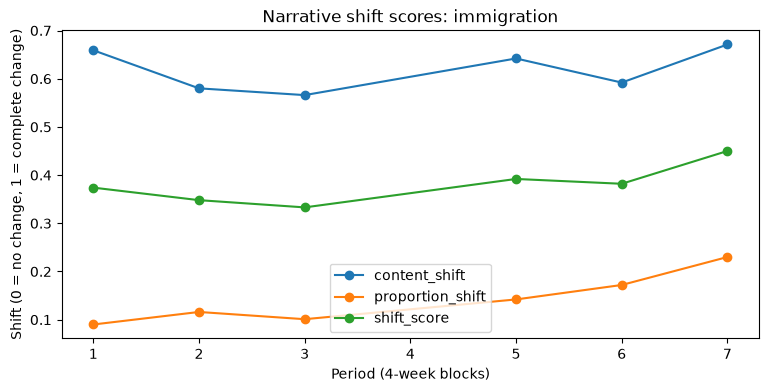

In [44]:
# Peaks=periods where the issue was reframed the most
ax = shift_df.plot(x="to_period", y=["content_shift", "proportion_shift", "shift_score"], marker="o", figsize=(9, 4), title=f"Narrative shift scores: {ISSUE}")
ax.set_xlabel(f"Period ({PERIOD_WEEKS}-week blocks)")
ax.set_ylabel("Shift (0 = no change, 1 = complete change)")

### Feature Table for Supervised Models (one row per week per issue)

**(FYI: Blanks are expected)**:
- The first week of each issue (no previous week to compare).
- An issue's first fitted period (no previous period).
- Periods with fewer than "K × 10" tweets on the issue (too few to fit topics). In the sample, abortion and healthcare have too few tweets to get any shift scores.
- Weeks with no tweets on the issue (the topic shares are blank).

In [ ]:
def shift_between(A, B, threshold=0.2):
    pairs = match_topics(A["H"], B["H"], threshold)

    # Content shift: how much matched topics changed wording (0=same, 1=totally different)
    matched = [s for _, _, s, ok in pairs if ok]
    content_shift = np.mean([1 - s for s in matched]) if matched else 1.0

    # Proportion shift: how much attention moved between topics (0=same mix, 1=completely different)
    a_idx = [a for a, _, _, _ in pairs]
    b_idx = [b for _, b, _, _ in pairs]
    proportion_shift = jensenshannon(A["props"][a_idx], B["props"][b_idx], base=2)

    return {
        "content_shift": round(content_shift, 3),
        "proportion_shift": round(proportion_shift, 3),
        "new_frames": sum(1 for _, _, _, ok in pairs if not ok),
        "shift_score": round((content_shift + proportion_shift) / 2, 3),}


def run_issue(issue, period_weeks=PERIOD_WEEKS, k=K, threshold=0.2):
    """
    #Runs the pilot pipeline above (per period NMF + topic matching) for any issue, without printing.
    Returns one row per period with the shift scores for moving INTO that period from the
    previous fitted period. The first period has nothing to compare to, so it gets no row.
    """
    # Tweets about this issue with at great than or equal to 5 words, grouped into periods
    issue_tweets = df[df[f"issue_{issue}"]].copy()
    issue_tweets = issue_tweets[issue_tweets["cleanedTweet"].str.split().str.len() >= 5].reset_index(drop=True)
    issue_tweets["period"] = issue_tweets["week"] // period_weeks

    # One shared vocabulary per issue so the periods can be compared
    issue_vec = TfidfVectorizer(stop_words=custom_stops, max_df=0.95, min_df=2)
    X_issue = issue_vec.fit_transform(issue_tweets["cleanedTweet"])

    issue_models = {}
    for period, rows in sorted(issue_tweets.groupby("period").indices.items()):
        if len(rows) < k * 10:   # skip periods with too few tweets (same rule as the pilot)
            continue
        period_nmf = NMF(n_components=k, init="nndsvd", random_state=42, max_iter=500)
        W = period_nmf.fit_transform(X_issue[rows])
        issue_models[period] = {"H": period_nmf.components_, "props": W.sum(axis=0) / W.sum()}

    fitted = sorted(issue_models)
    rows = [{"period": p_b, "from_period": p_a, **shift_between(issue_models[p_a], issue_models[p_b], threshold)}
            for p_a, p_b in zip(fitted[:-1], fitted[1:])]
    columns = ["period", "from_period", "content_shift", "proportion_shift", "new_frames", "shift_score"]
    return pd.DataFrame(rows, columns=columns)
run_issue("immigration")

,period,from_period,content_shift,proportion_shift,new_frames,shift_score
0,1,0,0.659,0.090,1,0.374
1,2,1,0.580,0.116,2,0.348
2,3,2,0.566,0.101,3,0.333
3,5,3,0.642,0.142,1,0.392
4,6,5,0.592,0.172,1,0.382
5,7,6,0.671,0.230,2,0.450


In [ ]:
ISSUES = list(ISSUE_KEYWORDS)

# 1) Tweet counts: one row per week x issue
issue_cols = [f"issue_{i}" for i in ISSUES]
features = (
    df.groupby("week")[issue_cols].sum()
      .rename(columns=lambda c: c.removeprefix("issue_"))
      .reset_index()
      .melt(id_vars="week", var_name="issue", value_name="n_tweets_issue")
)

# 2) Week info: calendar dates (weeks are 7-day blocks starting Wed May 1, 2024),
#    total tweets, and how many days actually have data (weeks 13, 16, 17 have gaps)
first_day = pd.to_datetime(df["date"]).min()
week_info = df.groupby("week").agg(n_tweets_week=("week", "size"), days_with_data=("date", "nunique")).reset_index()
week_info["week_start"] = (first_day + pd.to_timedelta(week_info["week"] * 7, unit="D")).dt.date
week_info["week_end"] = (first_day + pd.to_timedelta(week_info["week"] * 7 + 6, unit="D")).dt.date
features = features.merge(week_info, on="week")

# 3) Issue share: what fraction of that week's tweets mention the issue, and its weekly change
features = features.sort_values(["issue", "week"]).reset_index(drop=True)
features["issue_share"] = features["n_tweets_issue"] / features["n_tweets_week"]
features["issue_share_change"] = features.groupby("issue")["issue_share"].diff()   # blank in week 0

# 4) Shift scores: every week in a period gets that periods scores (blank in each issue's first period
#    and in periods with too few tweets to fit topics)
features["period"] = features["week"] // PERIOD_WEEKS
all_shifts = pd.concat([run_issue(i).assign(issue=i) for i in ISSUES], ignore_index=True)
features = features.merge(all_shifts, on=["issue", "period"], how="left")

# 5) Topic shares: among this issue's tweets that week, the average share of each overall NMF topic
#    (Biden, Trump, ...). These topics have the same meaning every week, unlike the per-period topics.
topic_cols = ["topic_" + name.lower().replace(" ", "_") for name in weekly_topics.columns]
shares = pd.DataFrame(doc_topics, index=docs.index, columns=topic_cols)
shares = shares.div(shares.sum(axis=1), axis=0)   # each tweet's topic weights add up to 1
shares["week"] = df.loc[docs.index, "week"]
weekly_shares = pd.concat(
    [shares[df.loc[docs.index, f"issue_{i}"]].groupby("week")[topic_cols].mean().reset_index().assign(issue=i)
     for i in ISSUES],
    ignore_index=True,
)
features = features.merge(weekly_shares, on=["week", "issue"], how="left")

features = features[
    ["week", "week_start", "week_end", "issue", "n_tweets_issue", "n_tweets_week", "days_with_data",
     "issue_share", "issue_share_change", "period", "from_period", "content_shift", "proportion_shift",
     "new_frames", "shift_score"] + topic_cols
]
features.to_csv("../DataFiles/tk_issue_week_features.csv", index=False)
print(features.shape, "-> saved to DataFiles/tk_issue_week_features.csv")
features.head(12)

(186, 20) -> saved to DataFiles/tk_issue_week_features.csv


,week,week_start,week_end,issue,n_tweets_issue,n_tweets_week,days_with_data,issue_share,issue_share_change,period,from_period,content_shift,proportion_shift,new_frames,shift_score,topic_biden,topic_trump,topic_maga_movement,topic_harris,topic_partisan_talk
0,0,2024-05-01,2024-05-07,abortion,3,900,7,0.003333,NaN,0,NaN,NaN,NaN,NaN,NaN,0.375563,0.105187,0.067378,0.051392,0.400480
1,1,2024-05-08,2024-05-14,abortion,5,1000,7,0.005000,0.001667,0,NaN,NaN,NaN,NaN,NaN,0.078517,0.077915,0.100131,0.268272,0.475166
2,2,2024-05-15,2024-05-21,abortion,3,540,7,0.005556,0.000556,0,NaN,NaN,NaN,NaN,NaN,0.142126,0.029754,0.109895,0.027713,0.690512
3,3,2024-05-22,2024-05-28,abortion,2,740,7,0.002703,-0.002853,0,NaN,NaN,NaN,NaN,NaN,0.102790,0.058823,0.049227,0.089535,0.699624
4,4,2024-05-29,2024-06-04,abortion,3,719,7,0.004172,0.001470,1,NaN,NaN,NaN,NaN,NaN,0.059099,0.322801,0.086076,0.058158,0.473867
5,5,2024-06-05,2024-06-11,abortion,8,818,7,0.009780,0.005607,1,NaN,NaN,NaN,NaN,NaN,0.078541,0.117743,0.034409,0.113696,0.655610
6,6,2024-06-12,2024-06-18,abortion,15,1450,7,0.010345,0.000565,1,NaN,NaN,NaN,NaN,NaN,0.149000,0.078025,0.164976,0.036982,0.571017
7,7,2024-06-19,2024-06-25,abortion,11,940,7,0.011702,0.001357,1,NaN,NaN,NaN,NaN,NaN,0.134630,0.143899,0.101831,0.053022,0.566618
8,8,2024-06-26,2024-07-02,abortion,7,645,7,0.010853,-0.000849,2,NaN,NaN,NaN,NaN,NaN,0.190811,0.281258,0.212056,0.020655,0.295220
9,9,2024-07-03,2024-07-09,abortion,12,1235,7,0.009717,-0.001136,2,NaN,NaN,NaN,NaN,NaN,0.094272,0.153478,0.047583,0.163136,0.541530
